<a href="https://colab.research.google.com/github/rubenzito/localidadespalhamento/blob/main/T%C3%B3pico_2__Tratamento_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook Colab: imputação, ruído, outliers, rótulos corrompidos e conversão simbólica-numérica

Este notebook foi preparado em formato **didático** para uso no **Google Colab** e simula uma aplicação de **monitoramento industrial e controle de qualidade** em uma linha de produção.

## Cenário didático

Imagine uma fábrica que monitora lotes de produção por meio de sensores e registros operacionais.  
Para cada lote, coletamos variáveis como:

- temperatura do forno,
- pressão da linha,
- vibração do motor,
- velocidade da esteira,
- umidade do ambiente,
- corrente elétrica,
- turno de operação,
- tipo de matéria-prima,
- família do produto,
- prioridade do lote,
- indicação de manutenção recente.

Na prática, esse tipo de base costuma apresentar:

- **valores ausentes**;
- **ruídos de medição**;
- **outliers**;
- **variáveis categóricas** que precisam ser convertidas para números;
- e, em alguns casos, até **rótulos corrompidos**.

## Objetivos

Ao final deste material, você deverá ser capaz de:


1. Entender a diferença entre **ruído** e **outlier**;
2. Aplicar e comparar **técnicas de imputação**;
3. Usar uma técnica de **encestamento (ensemble/bagging)** para detectar observações suspeitas;
4. Aplicar **DBSCAN** para detectar ruído em regiões de baixa densidade;
5. Aplicar **Local Outlier Factor (LOF)** para detectar outliers locais;
6. Simular e estudar **rótulos corrompidos (noisy labels)**;
7. Aplicar técnicas de **conversão simbólica-numérica** de atributos categóricos.

---

## Parte I - Técnicas de imputação que serão estudadas

1. **Valor constante**: criar uma categoria como `"Desconhecido"`;
2. **Média**: útil para variáveis numéricas aproximadamente simétricas;
3. **Mediana**: mais robusta a outliers;
4. **Moda / valor mais frequente**: útil para variáveis categóricas;
5. **Frequência local / vizinhos próximos**: aproximada aqui com `KNNImputer`;
6. **Comparação entre resultados**.

> **Importante:** não existe uma única técnica “sempre correta”.  
> A escolha depende do tipo de variável, da quantidade de ausências e do contexto do problema.

## Parte II - Ruído, outliers e rótulos corrompidos

Vamos estudar:

- diferença entre **ruído** e **outlier**;
- detecção com **ensemble/bagging**;
- detecção com **DBSCAN**;
- detecção com **LOF**;
- efeito de **rótulos corrompidos**.

## Parte III - Conversão simbólica-numérica

As técnicas serão apresentadas nesta ordem:

1. **Label Encoding**
2. **One-Hot Encoding**
3. **Binary Encoding**
4. **Ordinal Encoding**
5. **Frequency Encoding**

Nosso foco será a **conversão de variáveis categóricas para números**.

---

## Como usar este notebook

A proposta é **ensinar conceito + prática em Python**.  
Em cada etapa, você verá:

- uma explicação conceitual;
- o código Python usado;
- gráficos e tabelas;
- uma interpretação didática dos resultados.

In [8]:
# Instalação opcional para o Google Colab
# category_encoders será usado na parte de Binary Encoding.
# Se você estiver no Colab, basta rodar esta célula uma vez.
try:
    import category_encoders  # noqa: F401
except Exception:
    !pip -q install category_encoders

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor

import category_encoders as ce

np.random.seed(42)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 1. Geração da base sintética

Vamos criar uma base sintética com **1.500 lotes de produção**.

### Ideia da simulação

Cada linha representará um lote.  
Teremos variáveis numéricas e categóricas, além de um rótulo binário:

- `falha_qualidade = 1`: lote com maior chance de problema;
- `falha_qualidade = 0`: lote sem falha.

### Como o Python será usado aqui?

Usaremos principalmente:

- `numpy` para gerar valores aleatórios;
- `pandas` para organizar os dados em tabela (`DataFrame`);
- fórmulas simples para induzir relações entre variáveis e o rótulo.

In [10]:
n = 1500

turnos = np.random.choice(["Manhã", "Tarde", "Noite"], size=n, p=[0.35, 0.40, 0.25])
materias = np.random.choice(["Aço", "Alumínio", "Compósito", "Polímero"], size=n, p=[0.30, 0.25, 0.20, 0.25])
produtos = np.random.choice(["Válvula", "Bomba", "Sensor"], size=n, p=[0.45, 0.30, 0.25])
manutencao = np.random.choice(["Sim", "Não"], size=n, p=[0.30, 0.70])
prioridade = np.random.choice(["Baixa", "Média", "Alta"], size=n, p=[0.35, 0.45, 0.20])

# Efeitos por categoria para deixar a base mais realista
efeito_turno = pd.Series(turnos).map({"Manhã": -2.0, "Tarde": 0.0, "Noite": 2.5}).to_numpy()
efeito_material_temp = pd.Series(materias).map({"Aço": 8, "Alumínio": -4, "Compósito": 6, "Polímero": -8}).to_numpy()
efeito_material_vib = pd.Series(materias).map({"Aço": 0.2, "Alumínio": -0.1, "Compósito": 0.5, "Polímero": 0.0}).to_numpy()
efeito_produto_pressao = pd.Series(produtos).map({"Válvula": 0.2, "Bomba": 0.5, "Sensor": -0.2}).to_numpy()
efeito_manutencao = pd.Series(manutencao).map({"Sim": -0.5, "Não": 0.8}).to_numpy()
efeito_prioridade = pd.Series(prioridade).map({"Baixa": -0.2, "Média": 0.0, "Alta": 0.3}).to_numpy()

temperatura_forno = 710 + efeito_turno + efeito_material_temp + np.random.normal(0, 12, n)
pressao_linha = 5.2 + efeito_produto_pressao + np.random.normal(0, 0.45, n)
vibracao_motor = 3.0 + efeito_material_vib + efeito_manutencao + np.random.normal(0, 0.55, n)
velocidade_esteira = 52 + np.random.normal(0, 5.5, n) - 1.2 * efeito_prioridade
umidade_ambiente = 46 + np.random.normal(0, 8, n)
corrente_eletrica = 118 + 0.05 * (temperatura_forno - 710) + 1.6 * vibracao_motor + np.random.normal(0, 4, n)

df_clean = pd.DataFrame({
    "temperatura_forno": temperatura_forno,
    "pressao_linha": pressao_linha,
    "vibracao_motor": vibracao_motor,
    "velocidade_esteira": velocidade_esteira,
    "umidade_ambiente": umidade_ambiente,
    "corrente_eletrica": corrente_eletrica,
    "turno": turnos,
    "materia_prima": materias,
    "tipo_produto": produtos,
    "manutencao_recente": manutencao,
    "prioridade_lote": prioridade
})

# Probabilidade de falha de qualidade
z = (
    0.025 * (df_clean["temperatura_forno"] - 710)
    + 0.9 * (df_clean["vibracao_motor"] - 3.0)
    + 0.18 * (df_clean["corrente_eletrica"] - 118)
    - 0.15 * (df_clean["velocidade_esteira"] - 52)
    + 0.03 * (df_clean["umidade_ambiente"] - 46)
    + 0.35 * (df_clean["pressao_linha"] - 5.2)
    + pd.Series(manutencao).map({"Sim": -0.6, "Não": 0.3}).to_numpy()
    + pd.Series(turnos).map({"Manhã": -0.2, "Tarde": 0.1, "Noite": 0.4}).to_numpy()
    + np.random.normal(0, 0.6, n)
)

prob_falha = 1 / (1 + np.exp(-z))
falha_qualidade = (np.random.rand(n) < prob_falha).astype(int)
df_clean["falha_qualidade"] = falha_qualidade

df_clean.head()

,temperatura_forno,pressao_linha,vibracao_motor,velocidade_esteira,umidade_ambiente,corrente_eletrica,turno,materia_prima,tipo_produto,manutencao_recente,prioridade_lote,falha_qualidade
0,721.027,5.507,4.626,57.810,51.716,122.306,Tarde,Alumínio,Bomba,Não,Média,0
1,710.436,4.995,3.916,54.426,48.472,125.325,Noite,Alumínio,Sensor,Não,Baixa,1
2,725.729,4.890,2.102,51.714,47.072,119.654,Tarde,Aço,Válvula,Sim,Alta,0
3,706.984,6.163,2.332,51.927,41.106,120.472,Tarde,Alumínio,Bomba,Sim,Média,0
4,682.971,4.893,3.085,46.991,42.025,125.683,Manhã,Alumínio,Bomba,Não,Baixa,1


In [11]:
print("Dimensão da base limpa:", df_clean.shape)
display(df_clean.describe(include="all").T)

Dimensão da base limpa: (1500, 12)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
temperatura_forno,"1,500.000",NaN,NaN,NaN,710.409,14.306,663.464,700.652,710.370,720.175,751.317
pressao_linha,"1,500.000",NaN,NaN,NaN,5.403,0.526,3.340,5.066,5.399,5.741,7.121
vibracao_motor,"1,500.000",NaN,NaN,NaN,3.539,0.824,1.185,2.948,3.645,4.137,5.494
velocidade_esteira,"1,500.000",NaN,NaN,NaN,51.847,5.454,33.674,48.309,51.783,55.464,70.578
umidade_ambiente,"1,500.000",NaN,NaN,NaN,46.182,7.941,22.050,40.883,46.169,51.457,73.431
corrente_eletrica,"1,500.000",NaN,NaN,NaN,123.822,4.386,107.777,120.916,123.884,126.824,136.563
turno,1500,3,Tarde,587,NaN,NaN,NaN,NaN,NaN,NaN,NaN
materia_prima,1500,4,Aço,447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_produto,1500,3,Válvula,701,NaN,NaN,NaN,NaN,NaN,NaN,NaN
manutencao_recente,1500,2,Não,1048,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Inserindo ruído, outliers, ausências e rótulos corrompidos

Agora vamos contaminar a base para simular um cenário mais realista.

### Diferença entre ruído e outlier

- **Ruído**: contaminação difusa, geralmente pequena ou moderada, espalhada em várias observações.
- **Outlier**: ponto muito incomum, extremo, que foge fortemente do padrão.

### O que vamos fazer?

1. Adicionar **ruído** em parte das observações numéricas;
2. Inserir **outliers** fortes em poucos lotes;
3. Criar **valores ausentes** em colunas numéricas e categóricas;
4. Corromper parte dos **rótulos**.

Como a base é sintética, nós conhecemos a “verdade de origem”.  
Isso é ótimo para ensino, porque permite **comparar o que foi injetado com o que os algoritmos detectam**.

In [12]:
df = df_clean.copy()

num_cols = [
    "temperatura_forno", "pressao_linha", "vibracao_motor",
    "velocidade_esteira", "umidade_ambiente", "corrente_eletrica"
]
cat_cols = [
    "turno", "materia_prima", "tipo_produto",
    "manutencao_recente", "prioridade_lote"
]

# Máscaras para registrar o que foi contaminado
noise_mask = np.zeros(n, dtype=bool)
outlier_mask = np.zeros(n, dtype=bool)
missing_mask_numeric = pd.DataFrame(False, index=df.index, columns=num_cols)
missing_mask_categ = pd.DataFrame(False, index=df.index, columns=cat_cols)
label_corrupted_mask = np.zeros(n, dtype=bool)

# 1) Ruído difuso em 18% dos lotes
noise_idx = np.random.choice(df.index, size=int(0.18*n), replace=False)
noise_mask[noise_idx] = True

for col, scale in {
    "temperatura_forno": 10,
    "pressao_linha": 0.35,
    "vibracao_motor": 0.45,
    "velocidade_esteira": 4.0,
    "umidade_ambiente": 6.5,
    "corrente_eletrica": 5.0
}.items():
    df.loc[noise_idx, col] += np.random.normal(0, scale, len(noise_idx))

# 2) Outliers extremos em 3% dos lotes
remaining = np.setdiff1d(df.index, noise_idx)
outlier_idx = np.random.choice(remaining, size=int(0.03*n), replace=False)
outlier_mask[outlier_idx] = True

df.loc[outlier_idx, "temperatura_forno"] += np.random.choice([45, -50, 70], size=len(outlier_idx))
df.loc[outlier_idx, "vibracao_motor"] += np.random.choice([2.5, 3.5, 4.2], size=len(outlier_idx))
df.loc[outlier_idx, "corrente_eletrica"] += np.random.choice([20, -18, 30], size=len(outlier_idx))
df.loc[outlier_idx, "pressao_linha"] += np.random.choice([1.8, -1.2, 2.2], size=len(outlier_idx))

# 3) Ausências em 12% dos lotes, afetando algumas colunas
for col, frac in {
    "temperatura_forno": 0.08,
    "pressao_linha": 0.06,
    "vibracao_motor": 0.10,
    "umidade_ambiente": 0.07,
    "turno": 0.05,
    "materia_prima": 0.06,
    "manutencao_recente": 0.04
}.items():
    idx = np.random.choice(df.index, size=int(frac*n), replace=False)
    if col in num_cols:
        missing_mask_numeric.loc[idx, col] = True
    else:
        missing_mask_categ.loc[idx, col] = True
    df.loc[idx, col] = np.nan

# 4) Rótulos corrompidos em 10% dos lotes
label_idx = np.random.choice(df.index, size=int(0.10*n), replace=False)
label_corrupted_mask[label_idx] = True
df["falha_qualidade_corrompida"] = df_clean["falha_qualidade"].copy()
df.loc[label_idx, "falha_qualidade_corrompida"] = 1 - df.loc[label_idx, "falha_qualidade_corrompida"]

df["tipo_contaminacao"] = "normal"
df.loc[noise_mask, "tipo_contaminacao"] = "ruido"
df.loc[outlier_mask, "tipo_contaminacao"] = "outlier"

display(df.head())
print("Ruídos injetados:", noise_mask.sum())
print("Outliers injetados:", outlier_mask.sum())
print("Rótulos corrompidos:", label_corrupted_mask.sum())
print("Ausências por coluna:")
display(df.isna().sum())

,temperatura_forno,pressao_linha,vibracao_motor,velocidade_esteira,umidade_ambiente,corrente_eletrica,turno,materia_prima,tipo_produto,manutencao_recente,prioridade_lote,falha_qualidade,falha_qualidade_corrompida,tipo_contaminacao
0,725.748,5.463,4.561,55.093,52.185,124.148,Tarde,Alumínio,Bomba,Não,Média,0,0,ruido
1,710.436,4.995,3.916,54.426,48.472,125.325,Noite,Alumínio,Sensor,Não,Baixa,1,1,normal
2,747.438,4.472,2.817,40.905,43.974,126.028,Tarde,Aço,Válvula,Sim,Alta,0,0,ruido
3,NaN,6.163,2.332,51.927,41.106,120.472,Tarde,Alumínio,Bomba,Sim,Média,0,0,normal
4,682.971,4.893,3.085,46.991,42.025,125.683,Manhã,Alumínio,Bomba,Não,Baixa,1,1,normal


Ruídos injetados: 270
Outliers injetados: 45
Rótulos corrompidos: 150
Ausências por coluna:


,0
temperatura_forno,120
pressao_linha,90
vibracao_motor,150
velocidade_esteira,0
umidade_ambiente,105
corrente_eletrica,0
turno,75
materia_prima,90
tipo_produto,0
manutencao_recente,60


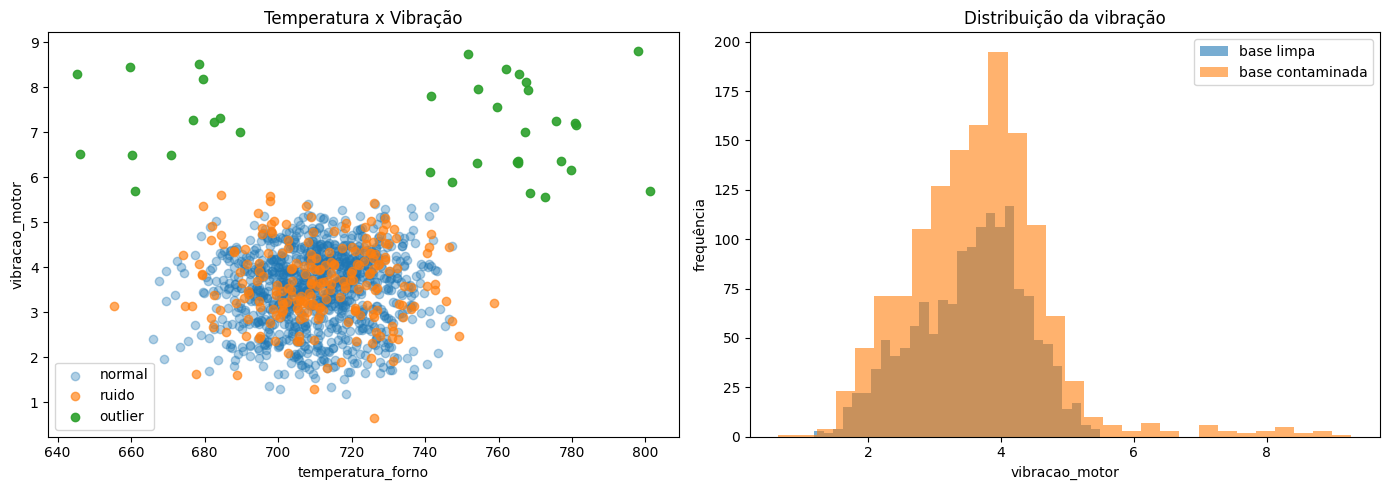

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: dispersão com tipos de contaminação
for classe, alpha in [("normal", 0.35), ("ruido", 0.65), ("outlier", 0.9)]:
    temp = df[df["tipo_contaminacao"] == classe]
    axes[0].scatter(temp["temperatura_forno"], temp["vibracao_motor"], alpha=alpha, label=classe)

axes[0].set_title("Temperatura x Vibração")
axes[0].set_xlabel("temperatura_forno")
axes[0].set_ylabel("vibracao_motor")
axes[0].legend()

# Gráfico 2: distribuição da vibração com e sem contaminação
axes[1].hist(df_clean["vibracao_motor"], bins=30, alpha=0.6, label="base limpa")
axes[1].hist(df["vibracao_motor"].dropna(), bins=30, alpha=0.6, label="base contaminada")
axes[1].set_title("Distribuição da vibração")
axes[1].set_xlabel("vibracao_motor")
axes[1].set_ylabel("frequência")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretação

No gráfico de dispersão, os **outliers** tendem a ficar mais afastados das nuvens principais.  
Já o **ruído** pode não formar pontos tão extremos: ele “embaralha” as medidas e torna o problema mais sutil.

No histograma, vemos que a base contaminada costuma ficar:

- mais espalhada;
- com caudas mais longas;
- e às vezes com valores extremos adicionais.

---

## 3. Estudo de imputação

Vamos trabalhar agora com os **valores ausentes**.

### Técnicas que serão aplicadas

1. **Valor constante**
2. **Média**
3. **Mediana**
4. **Moda**
5. **KNNImputer**
6. **Comparação entre os resultados**

### Observação importante

Para variáveis categóricas, média e mediana não fazem sentido.  
Para esse tipo de variável, são mais naturais:

- **valor constante**;
- **moda**.

Já em variáveis numéricas, média, mediana e KNN podem ser úteis.

In [14]:
# Vamos separar a base com ausências
X_missing = df[num_cols + cat_cols].copy()

print("Quantidade total de ausências:")
print(X_missing.isna().sum().sort_values(ascending=False))

Quantidade total de ausências:
vibracao_motor        150
temperatura_forno     120
umidade_ambiente      105
pressao_linha          90
materia_prima          90
turno                  75
manutencao_recente     60
corrente_eletrica       0
velocidade_esteira      0
tipo_produto            0
prioridade_lote         0
dtype: int64


## 3.1 Imputação por valor constante

### Conceito

Na imputação por valor constante:

- em variáveis categóricas, é comum criar uma categoria como `"Desconhecido"`;
- em variáveis numéricas, podemos usar um valor fixo, mas isso deve ser feito com cuidado.

Neste notebook, vamos usar:

- `"Desconhecido"` para categóricas;
- `-999` apenas como demonstração numérica.

> Em problemas reais, usar um número extremo como `-999` pode distorcer análises.  
> É didático aqui, mas nem sempre é uma boa prática.

In [15]:
constant_num_imputer = SimpleImputer(strategy="constant", fill_value=-999)
constant_cat_imputer = SimpleImputer(strategy="constant", fill_value="Desconhecido")

X_constant = X_missing.copy()
X_constant[num_cols] = constant_num_imputer.fit_transform(X_constant[num_cols])
X_constant[cat_cols] = constant_cat_imputer.fit_transform(X_constant[cat_cols])

display(X_constant.head())

,temperatura_forno,pressao_linha,vibracao_motor,velocidade_esteira,umidade_ambiente,corrente_eletrica,turno,materia_prima,tipo_produto,manutencao_recente,prioridade_lote
0,725.748,5.463,4.561,55.093,52.185,124.148,Tarde,Alumínio,Bomba,Não,Média
1,710.436,4.995,3.916,54.426,48.472,125.325,Noite,Alumínio,Sensor,Não,Baixa
2,747.438,4.472,2.817,40.905,43.974,126.028,Tarde,Aço,Válvula,Sim,Alta
3,-999.000,6.163,2.332,51.927,41.106,120.472,Tarde,Alumínio,Bomba,Sim,Média
4,682.971,4.893,3.085,46.991,42.025,125.683,Manhã,Alumínio,Bomba,Não,Baixa


### Como o Python foi usado?

Usamos a classe `SimpleImputer` do `sklearn.impute`.

- `strategy="constant"` diz ao Python para preencher com um valor fixo;
- `fill_value="Desconhecido"` define a nova categoria;
- `fit_transform(...)` aprende a regra e já devolve a matriz transformada.

Esse padrão (`fit`, `transform`, `fit_transform`) aparece muito em machine learning com `scikit-learn`.

## 3.2 Imputação pela média

### Conceito

A média é uma escolha simples e comum para variáveis numéricas **aproximadamente simétricas**.

Vantagem:
- simples e rápida.

Desvantagem:
- **sensível a outliers**.

Como nossa base tem outliers, isso será relevante na comparação.

In [16]:
mean_imputer = SimpleImputer(strategy="mean")

X_mean = X_missing.copy()
X_mean[num_cols] = mean_imputer.fit_transform(X_mean[num_cols])
X_mean[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(X_mean[cat_cols])

display(X_mean[num_cols].head())

,temperatura_forno,pressao_linha,vibracao_motor,velocidade_esteira,umidade_ambiente,corrente_eletrica
0,725.748,5.463,4.561,55.093,52.185,124.148
1,710.436,4.995,3.916,54.426,48.472,125.325
2,747.438,4.472,2.817,40.905,43.974,126.028
3,711.084,6.163,2.332,51.927,41.106,120.472
4,682.971,4.893,3.085,46.991,42.025,125.683


## 3.3 Imputação pela mediana

### Conceito

A mediana é mais **robusta a outliers** do que a média.

Por isso, quando existe a possibilidade de valores extremos, a mediana costuma ser uma alternativa muito boa.

In [17]:
median_imputer = SimpleImputer(strategy="median")

X_median = X_missing.copy()
X_median[num_cols] = median_imputer.fit_transform(X_median[num_cols])
X_median[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(X_median[cat_cols])

display(X_median[num_cols].head())

,temperatura_forno,pressao_linha,vibracao_motor,velocidade_esteira,umidade_ambiente,corrente_eletrica
0,725.748,5.463,4.561,55.093,52.185,124.148
1,710.436,4.995,3.916,54.426,48.472,125.325
2,747.438,4.472,2.817,40.905,43.974,126.028
3,710.461,6.163,2.332,51.927,41.106,120.472
4,682.971,4.893,3.085,46.991,42.025,125.683


## 3.4 Imputação pela moda

### Conceito

A moda corresponde ao **valor mais frequente**.

Ela é bastante usada para variáveis categóricas, mas também pode ser aplicada em variáveis numéricas discretizadas.

In [18]:
mode_imputer = SimpleImputer(strategy="most_frequent")

X_mode = X_missing.copy()
X_mode[num_cols] = mode_imputer.fit_transform(X_mode[num_cols])
X_mode[cat_cols] = mode_imputer.fit_transform(X_mode[cat_cols])

display(X_mode.head())

,temperatura_forno,pressao_linha,vibracao_motor,velocidade_esteira,umidade_ambiente,corrente_eletrica,turno,materia_prima,tipo_produto,manutencao_recente,prioridade_lote
0,725.748,5.463,4.561,55.093,52.185,124.148,Tarde,Alumínio,Bomba,Não,Média
1,710.436,4.995,3.916,54.426,48.472,125.325,Noite,Alumínio,Sensor,Não,Baixa
2,747.438,4.472,2.817,40.905,43.974,126.028,Tarde,Aço,Válvula,Sim,Alta
3,645.245,6.163,2.332,51.927,41.106,120.472,Tarde,Alumínio,Bomba,Sim,Média
4,682.971,4.893,3.085,46.991,42.025,125.683,Manhã,Alumínio,Bomba,Não,Baixa


## 3.5 Imputação por frequência local / vizinhos próximos com `KNNImputer`

### Conceito

A ideia do `KNNImputer` é preencher valores ausentes usando observações **parecidas**.

Em termos intuitivos:

1. o algoritmo procura os **vizinhos mais próximos**;
2. usa esses vizinhos para estimar o valor faltante.

### Observação

O `KNNImputer` trabalha com números.  
Por isso, primeiro vamos converter temporariamente as variáveis categóricas para códigos numéricos apenas para viabilizar o processo.  
Depois, arredondaremos os códigos categóricos e mapearemos de volta para suas categorias.

In [19]:
# Conversão temporária de categorias para códigos
X_knn_temp = X_missing.copy()

category_maps = {}
inverse_maps = {}

for col in cat_cols:
    categorias = pd.Series(df_clean[col].dropna().unique()).sort_values().tolist()
    category_maps[col] = {cat: i for i, cat in enumerate(categorias)}
    inverse_maps[col] = {i: cat for cat, i in category_maps[col].items()}
    X_knn_temp[col] = X_knn_temp[col].map(category_maps[col])

knn_imputer = KNNImputer(n_neighbors=5)
X_knn_arr = knn_imputer.fit_transform(X_knn_temp)

X_knn = pd.DataFrame(X_knn_arr, columns=X_knn_temp.columns)

# Reconstrução das categorias
for col in cat_cols:
    X_knn[col] = X_knn[col].round().clip(lower=0)
    X_knn[col] = X_knn[col].map(lambda x: inverse_maps[col].get(int(x), list(inverse_maps[col].values())[0]))

display(X_knn.head())

,temperatura_forno,pressao_linha,vibracao_motor,velocidade_esteira,umidade_ambiente,corrente_eletrica,turno,materia_prima,tipo_produto,manutencao_recente,prioridade_lote
0,725.748,5.463,4.561,55.093,52.185,124.148,Tarde,Alumínio,Bomba,Não,Média
1,710.436,4.995,3.916,54.426,48.472,125.325,Noite,Alumínio,Sensor,Não,Baixa
2,747.438,4.472,2.817,40.905,43.974,126.028,Tarde,Aço,Válvula,Sim,Alta
3,701.223,6.163,2.332,51.927,41.106,120.472,Tarde,Alumínio,Bomba,Sim,Média
4,682.971,4.893,3.085,46.991,42.025,125.683,Manhã,Alumínio,Bomba,Não,Baixa


### Como o Python foi usado aqui?

Observe a sequência:

- `map(...)` converte categorias para números;
- `KNNImputer(...)` aplica a imputação;
- depois usamos novo `map(...)` para voltar da codificação numérica para o texto original.

Esse tipo de pré-processamento é comum quando um algoritmo exige entrada numérica.

## 3.6 Comparação entre os métodos de imputação

Como a base é sintética, nós sabemos quais eram os **valores originais** antes de inserir ausências.  
Isso nos permite comparar o valor imputado com o valor verdadeiro.

### Métrica didática

Vamos usar o **RMSE** apenas sobre as posições que ficaram ausentes nas variáveis numéricas.

Quanto **menor** o RMSE, melhor foi a recuperação aproximada dos valores.

In [20]:
def rmse_on_missing(original_df, imputed_df, mask_df, columns):
    resultados = []
    for col in columns:
        idx = mask_df.index[mask_df[col]]
        if len(idx) > 0:
            rmse = mean_squared_error(original_df.loc[idx, col], imputed_df.loc[idx, col], squared=False)
            resultados.append([col, len(idx), rmse])
    return pd.DataFrame(resultados, columns=["coluna", "n_ausentes", "RMSE"])

comp_constant = rmse_on_missing(df_clean, X_constant, missing_mask_numeric, num_cols)
comp_mean = rmse_on_missing(df_clean, X_mean, missing_mask_numeric, num_cols)
comp_median = rmse_on_missing(df_clean, X_median, missing_mask_numeric, num_cols)
comp_mode = rmse_on_missing(df_clean, X_mode, missing_mask_numeric, num_cols)
comp_knn = rmse_on_missing(df_clean, X_knn, missing_mask_numeric, num_cols)

comparacao_imput = pd.DataFrame({"coluna": num_cols})
for nome, tabela in {
    "Constante": comp_constant,
    "Média": comp_mean,
    "Mediana": comp_median,
    "Moda": comp_mode,
    "KNN": comp_knn
}.items():
    comparacao_imput = comparacao_imput.merge(
        tabela[["coluna", "RMSE"]].rename(columns={"RMSE": nome}),
        on="coluna",
        how="left"
    )

display(comparacao_imput)

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
ax = comparacao_imput.set_index("coluna").plot(kind="bar", figsize=(12, 5))
ax.set_title("Comparação de RMSE por método de imputação")
ax.set_ylabel("RMSE (menor é melhor)")
ax.set_xlabel("Variável")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Interpretação da comparação

Em geral, você deverá observar algo próximo do seguinte comportamento:

- **média** funciona razoavelmente quando a variável é mais estável;
- **mediana** tende a se sair melhor quando há **outliers**;
- **moda** não costuma ser boa para variáveis numéricas contínuas;
- **KNN** pode capturar relações locais e funcionar bem quando há estrutura entre as variáveis;
- **valor constante** é útil para sinalizar ausência, mas não necessariamente para reconstruir bem o valor numérico.

> **Lembrete:** não existe uma técnica universalmente melhor.
> A escolha depende da natureza do dado e do objetivo do modelo.

## 4. Comparação do efeito da imputação em um modelo preditivo

Além de comparar o valor imputado com o original, também é útil analisar o efeito em um **modelo de classificação**.

Vamos montar um pipeline simples:

- imputação;
- one-hot encoding para variáveis categóricas;
- `RandomForestClassifier`.

A métrica será a **acurácia** usando o rótulo limpo `falha_qualidade`.

In [ ]:
y_clean = df_clean["falha_qualidade"].copy()
X_base = df[num_cols + cat_cols].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y_clean, test_size=0.30, random_state=42, stratify=y_clean
)

def build_pipeline(num_strategy="mean", cat_strategy="most_frequent", use_knn=False):
    if use_knn:
        # Para simplificar o pipeline, KNN ficará fora deste comparativo final.
        return None

    num_imputer = SimpleImputer(strategy=num_strategy)
    cat_imputer = SimpleImputer(strategy=cat_strategy, fill_value="Desconhecido" if cat_strategy == "constant" else None)

    preprocessor = ColumnTransformer([
        ("num", Pipeline([("imputer", num_imputer)]), num_cols),
        ("cat", Pipeline([
            ("imputer", cat_imputer),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ])

    model = Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=250, random_state=42))
    ])
    return model

configs = {
    "Constante": dict(num_strategy="constant", cat_strategy="constant"),
    "Média": dict(num_strategy="mean", cat_strategy="most_frequent"),
    "Mediana": dict(num_strategy="median", cat_strategy="most_frequent"),
    "Moda": dict(num_strategy="most_frequent", cat_strategy="most_frequent"),
}

resultados_modelo = []
for nome, cfg in configs.items():
    model = build_pipeline(**cfg)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    resultados_modelo.append([nome, acc])

resultados_modelo = pd.DataFrame(resultados_modelo, columns=["Método de imputação", "Acurácia"])
display(resultados_modelo.sort_values("Acurácia", ascending=False))

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(resultados_modelo["Método de imputação"], resultados_modelo["Acurácia"])
plt.title("Impacto da imputação na acurácia do modelo")
plt.ylabel("Acurácia")
plt.ylim(max(0, resultados_modelo["Acurácia"].min() - 0.05), min(1, resultados_modelo["Acurácia"].max() + 0.05))
plt.tight_layout()
plt.show()

## 5. Detecção de ruído e outliers

Agora vamos usar três abordagens:

1. **Ensemble / bagging** com várias execuções de `IsolationForest`;
2. **DBSCAN** para pontos em regiões de baixa densidade;
3. **Local Outlier Factor (LOF)** para outliers locais.

Para facilitar, vamos trabalhar apenas com as **variáveis numéricas imputadas pela mediana**.  
Essa escolha é razoável porque a mediana tende a ser robusta à presença de outliers.

In [ ]:
X_num_ready = X_median[num_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num_ready)

X_scaled[:5]

## 5.1 Ensemble / bagging para observações suspeitas

### Ideia didática

Vamos treinar várias `IsolationForest` em **amostras bootstrap** da base.  
Depois, agregaremos os resultados.

Se uma observação for marcada muitas vezes como anômala, ela será considerada mais suspeita.

Isso representa a ideia de **encestamento (ensemble/bagging)**:  
combinar múltiplos detectores para obter uma decisão mais estável.

In [ ]:
n_models = 25
scores = np.zeros(len(X_scaled))
flags = np.zeros(len(X_scaled))

for seed in range(n_models):
    boot_idx = np.random.choice(np.arange(len(X_scaled)), size=len(X_scaled), replace=True)
    X_boot = X_scaled[boot_idx]

    iso = IsolationForest(contamination=0.05, random_state=100 + seed)
    iso.fit(X_boot)

    decision = iso.decision_function(X_scaled)
    pred = iso.predict(X_scaled)  # -1 anômalo, 1 normal

    scores += -decision
    flags += (pred == -1).astype(int)

scores /= n_models
flags_ratio = flags / n_models
ensemble_pred = flags_ratio >= 0.5

df_detect = pd.DataFrame({
    "score_ensemble": scores,
    "flag_ratio": flags_ratio,
    "ensemble_anomalo": ensemble_pred,
    "ruido_real": noise_mask,
    "outlier_real": outlier_mask,
    "contaminado_real": noise_mask | outlier_mask
})

display(df_detect.head())

In [ ]:
print("Observações sinalizadas pelo ensemble:", df_detect["ensemble_anomalo"].sum())

tabela_ensemble = pd.crosstab(
    df_detect["contaminado_real"],
    df_detect["ensemble_anomalo"],
    rownames=["contaminação real"],
    colnames=["sinalizado pelo ensemble"]
)
display(tabela_ensemble)

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_median["temperatura_forno"], X_median["vibracao_motor"],
    c=df_detect["flag_ratio"], alpha=0.6
)
plt.colorbar(label="Fração de vezes sinalizado")
plt.xlabel("temperatura_forno")
plt.ylabel("vibracao_motor")
plt.title("Ensemble/bagging: intensidade de suspeita")
plt.tight_layout()
plt.show()

### Interpretação

Quanto maior a **fração de sinalizações**, mais suspeita é a observação.  
Esse tipo de abordagem é interessante porque reduz a dependência de uma única execução aleatória do detector.

## 5.2 DBSCAN

### Conceito

`DBSCAN` é um algoritmo de agrupamento baseado em densidade.

Ele procura regiões densas de pontos e rotula como `-1` os pontos que ficam em áreas de baixa densidade.  
Esses pontos são frequentemente interpretados como **ruído**.

In [ ]:
dbscan = DBSCAN(eps=1.35, min_samples=12)
db_labels = dbscan.fit_predict(X_scaled)

db_noise = db_labels == -1

print("Pontos rotulados como ruído pelo DBSCAN:", db_noise.sum())

tabela_dbscan = pd.crosstab(
    noise_mask | outlier_mask,
    db_noise,
    rownames=["contaminação real"],
    colnames=["rotulado como ruído pelo DBSCAN"]
)
display(tabela_dbscan)

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_median["temperatura_forno"], X_median["vibracao_motor"],
    c=db_labels, alpha=0.65
)
plt.xlabel("temperatura_forno")
plt.ylabel("vibracao_motor")
plt.title("DBSCAN: rótulos dos grupos (-1 = ruído)")
plt.tight_layout()
plt.show()

### Interpretação

O DBSCAN é especialmente útil quando:

- existem grupos bem definidos;
- e pontos afastados das regiões densas podem ser tratados como ruído.

Ele pode falhar quando a base possui densidades muito diferentes em regiões distintas.

## 5.3 Local Outlier Factor (LOF)

### Conceito

O LOF compara a densidade local de uma observação com a densidade dos seus vizinhos.

Se a densidade local for muito menor que a dos vizinhos, o ponto tende a ser considerado um **outlier local**.

In [ ]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_pred = lof.fit_predict(X_scaled)  # -1 = outlier
lof_score = -lof.negative_outlier_factor_
lof_outlier = lof_pred == -1

print("Pontos rotulados como outlier pelo LOF:", lof_outlier.sum())

tabela_lof = pd.crosstab(
    outlier_mask,
    lof_outlier,
    rownames=["outlier real"],
    colnames=["rotulado como outlier pelo LOF"]
)
display(tabela_lof)

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_median["temperatura_forno"], X_median["vibracao_motor"],
    c=lof_score, alpha=0.65
)
plt.colorbar(label="score LOF")
plt.xlabel("temperatura_forno")
plt.ylabel("vibracao_motor")
plt.title("LOF: intensidade de anomalia local")
plt.tight_layout()
plt.show()

### Comparando os três métodos

- **Ensemble/bagging**: maior estabilidade, pois combina vários detectores;
- **DBSCAN**: bom para ruído em regiões pouco densas;
- **LOF**: muito útil para detectar **outliers locais**.

Como a base é sintética, você pode comparar o que cada método detecta com a contaminação real.

In [ ]:
comparacao_detectores = pd.DataFrame({
    "Método": ["Ensemble", "DBSCAN", "LOF"],
    "Sinalizados": [
        int(ensemble_pred.sum()),
        int(db_noise.sum()),
        int(lof_outlier.sum())
    ],
    "Interpretação principal": [
        "suspeitas agregadas por bagging",
        "ruído em baixa densidade",
        "outlier local"
    ]
})

display(comparacao_detectores)

## 6. Rótulos corrompidos (Noisy Labels)

Até aqui tratamos principalmente de problemas nos **atributos**.  
Agora vamos estudar um problema no **alvo** (`y`): rótulos incorretos.

### Ideia do experimento

Vamos treinar dois modelos com a mesma entrada:

1. usando o rótulo **limpo**;
2. usando o rótulo **corrompido**.

Depois avaliaremos ambos contra o **rótulo verdadeiro**.

In [ ]:
X_full = X_median.copy()
y_true = df_clean["falha_qualidade"].copy()
y_noisy = df["falha_qualidade_corrompida"].copy()

X_train, X_test, y_train_true, y_test_true, y_train_noisy, y_test_noisy = train_test_split(
    X_full, y_true, y_noisy, test_size=0.30, random_state=42, stratify=y_true
)

prep = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

model_clean = Pipeline([
    ("prep", prep),
    ("clf", RandomForestClassifier(n_estimators=250, random_state=42))
])

model_noisy = Pipeline([
    ("prep", prep),
    ("clf", RandomForestClassifier(n_estimators=250, random_state=42))
])

model_clean.fit(X_train, y_train_true)
model_noisy.fit(X_train, y_train_noisy)

pred_clean = model_clean.predict(X_test)
pred_noisy = model_noisy.predict(X_test)

acc_clean = accuracy_score(y_test_true, pred_clean)
acc_noisy = accuracy_score(y_test_true, pred_noisy)

print(f"Acurácia treinando com rótulos limpos:      {acc_clean:.4f}")
print(f"Acurácia treinando com rótulos corrompidos: {acc_noisy:.4f}")

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(["Treino com rótulo limpo", "Treino com rótulo corrompido"], [acc_clean, acc_noisy])
plt.title("Impacto dos rótulos corrompidos")
plt.ylabel("Acurácia no teste (avaliada contra o rótulo verdadeiro)")
plt.ylim(max(0, min(acc_clean, acc_noisy) - 0.08), min(1, max(acc_clean, acc_noisy) + 0.05))
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### Interpretação

Quando os rótulos de treino são corrompidos, o modelo aprende uma versão “embaralhada” do problema.  
Isso normalmente reduz a qualidade preditiva.

Em bases reais, noisy labels podem surgir por:

- erro humano de anotação;
- falha em sensores ou sistemas;
- regras de negócio inconsistentes;
- integração inadequada entre bases.

## 7. Conversão simbólica-numérica dos atributos categóricos

Agora vamos estudar cinco técnicas para transformar variáveis categóricas em números.

Usaremos estas colunas:

- `turno`
- `materia_prima`
- `tipo_produto`
- `manutencao_recente`
- `prioridade_lote`

Para simplificar, partiremos da base já imputada pela moda nas variáveis categóricas.

In [ ]:
X_cat_base = X_mode[cat_cols].copy()
display(X_cat_base.head())

## 7.1 Label Encoding

### Conceito

O **Label Encoding** transforma cada categoria em um número inteiro.

Exemplo:
- `Manhã -> 0`
- `Noite -> 1`
- `Tarde -> 2`

### Cuidado didático importante

Esse método **não preserva necessariamente significado ordinal real**.  
Ou seja, o algoritmo pode “achar” que 2 é maior que 1 de uma forma que faça sentido matemático, mas não semântico.

Por isso, ele costuma ser usado com mais cuidado em problemas com variáveis realmente nominais.

In [ ]:
le = LabelEncoder()

turno_label = le.fit_transform(X_cat_base["turno"])

df_label = pd.DataFrame({
    "turno_original": X_cat_base["turno"],
    "turno_codificado": turno_label
})

print("Mapeamento do LabelEncoder:")
for classe, codigo in zip(le.classes_, le.transform(le.classes_)):
    print(f"{classe} -> {codigo}")

display(df_label.head(10))

In [ ]:
plt.figure(figsize=(6, 4))
pd.Series(turno_label).value_counts().sort_index().plot(kind="bar")
plt.title("Label Encoding aplicado à variável 'turno'")
plt.xlabel("Código")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

### Como o Python foi usado?

- `LabelEncoder()` cria o codificador;
- `fit_transform(...)` aprende as categorias e devolve seus códigos;
- `classes_` guarda a ordem das categorias aprendidas.

## 7.2 One-Hot Encoding

### Conceito

No **One-Hot Encoding**, cada categoria vira uma nova coluna binária.

Exemplo:
- `turno_Manhã`
- `turno_Tarde`
- `turno_Noite`

Cada linha recebe:

- `1` na categoria correspondente;
- `0` nas demais.

### Vantagem

Não impõe uma ordem artificial entre categorias.

In [ ]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_arr = ohe.fit_transform(X_cat_base[["materia_prima"]])

ohe_cols = ohe.get_feature_names_out(["materia_prima"])
df_ohe = pd.DataFrame(ohe_arr, columns=ohe_cols)

display(pd.concat([X_cat_base[["materia_prima"]].head(10).reset_index(drop=True),
                   df_ohe.head(10).reset_index(drop=True)], axis=1))

In [ ]:
plt.figure(figsize=(8, 4))
df_ohe.sum().plot(kind="bar")
plt.title("One-Hot Encoding da variável 'materia_prima'")
plt.ylabel("Soma das ativações")
plt.tight_layout()
plt.show()

## 7.3 Binary Encoding

### Conceito

O **Binary Encoding** primeiro transforma cada categoria em um número inteiro e depois representa esse número em **binário**.

Ele costuma ser útil quando:

- há muitas categorias;
- e o one-hot criaria colunas demais.

Aqui vamos usar a biblioteca `category_encoders`.

In [ ]:
binary_encoder = ce.BinaryEncoder(cols=["tipo_produto"])
df_binary = binary_encoder.fit_transform(X_cat_base[["tipo_produto"]])

display(pd.concat([X_cat_base[["tipo_produto"]].head(10).reset_index(drop=True),
                   df_binary.head(10).reset_index(drop=True)], axis=1))

In [ ]:
plt.figure(figsize=(7, 4))
df_binary.sum().plot(kind="bar")
plt.title("Binary Encoding da variável 'tipo_produto'")
plt.ylabel("Soma dos bits")
plt.tight_layout()
plt.show()

## 7.4 Ordinal Encoding

### Conceito

O **Ordinal Encoding** deve ser usado quando a variável possui **ordem natural**.

No nosso caso, `prioridade_lote` tem uma ordem clara:

`Baixa < Média < Alta`

Então faz sentido mapear:

- `Baixa -> 0`
- `Média -> 1`
- `Alta -> 2`

In [ ]:
ord_encoder = OrdinalEncoder(categories=[["Baixa", "Média", "Alta"]])
prioridade_ord = ord_encoder.fit_transform(X_cat_base[["prioridade_lote"]])

df_ord = pd.DataFrame({
    "prioridade_original": X_cat_base["prioridade_lote"],
    "prioridade_codificada": prioridade_ord.flatten()
})

display(df_ord.head(10))

In [ ]:
plt.figure(figsize=(6, 4))
pd.Series(prioridade_ord.flatten()).value_counts().sort_index().plot(kind="bar")
plt.title("Ordinal Encoding da variável 'prioridade_lote'")
plt.xlabel("Código ordinal")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

## 7.5 Frequency Encoding

### Conceito

No **Frequency Encoding**, cada categoria é substituída por sua frequência de ocorrência.

Exemplo:
- se `Aço` aparece em 30% das linhas, então `Aço -> 0.30`.

### Quando ele pode ser útil?

- quando há muitas categorias;
- quando queremos uma representação compacta;
- em alguns modelos baseados em árvores isso pode funcionar bem.

### Limitação

Categorias diferentes podem receber valores próximos ou até iguais, o que reduz poder de discriminação.

In [ ]:
freq_map = X_cat_base["materia_prima"].value_counts(normalize=True).to_dict()
materia_freq = X_cat_base["materia_prima"].map(freq_map)

df_freq = pd.DataFrame({
    "materia_prima_original": X_cat_base["materia_prima"],
    "materia_prima_freq": materia_freq
})

print("Mapa de frequências:")
print(freq_map)
display(df_freq.head(10))

In [ ]:
plt.figure(figsize=(6, 4))
materia_freq.plot(kind="hist", bins=10)
plt.title("Distribuição dos valores após Frequency Encoding")
plt.xlabel("Frequência associada à categoria")
plt.tight_layout()
plt.show()

## 7.6 Comparação resumida das técnicas de encoding

A tabela abaixo resume a ideia principal de cada técnica.

In [ ]:
resumo_encoding = pd.DataFrame({
    "Técnica": [
        "Label Encoding",
        "One-Hot Encoding",
        "Binary Encoding",
        "Ordinal Encoding",
        "Frequency Encoding"
    ],
    "Quando usar": [
        "uso simples; cuidado com categorias nominais",
        "categorias nominais com poucas classes",
        "muitas categorias; reduzir dimensionalidade em relação ao one-hot",
        "quando existe ordem natural entre categorias",
        "quando se deseja representação compacta baseada na frequência"
    ],
    "Risco principal": [
        "introduzir ordem artificial",
        "explosão do número de colunas",
        "menor interpretabilidade dos bits",
        "ordem incorreta se mal definida",
        "perda de discriminação entre categorias"
    ]
})

display(resumo_encoding)

## 8. Conclusões do notebook

### Sobre imputação

- **valor constante** é útil para marcar ausência, especialmente em categóricas;
- **média** funciona bem em cenários mais simétricos;
- **mediana** é mais robusta a outliers;
- **moda** é muito útil para categóricas;
- **KNNImputer** tenta usar contexto local e pode recuperar melhor certas estruturas.

### Sobre ruído e outliers

- **ruído** é uma contaminação difusa;
- **outlier** é uma exceção mais extrema;
- **ensemble/bagging**, **DBSCAN** e **LOF** capturam aspectos diferentes do problema.

### Sobre noisy labels

- rótulos corrompidos podem degradar bastante o desempenho do modelo;
- esse problema afeta a aprendizagem supervisionada diretamente.

### Sobre encoding

- não existe uma técnica única ideal;
- a escolha depende:
  - do tipo da variável;
  - da presença ou não de ordem;
  - do número de categorias;
  - e do modelo usado.

---

## Próximos passos sugeridos ao aluno

Como exercício, você pode tentar:

1. mudar a taxa de ruído, outliers e ausência;
2. alterar os parâmetros do DBSCAN e do LOF;
3. comparar outros modelos de classificação;
4. testar qual encoding funciona melhor para cada tipo de modelo.

Esse tipo de experimentação ajuda muito a consolidar tanto os **conceitos** quanto o uso prático de **Python para machine learning**.

# Exercícios

## 1-Análise Exploratória

1. Quantos valores ausentes existem em cada variável?  





2. Quais variáveis parecem conter mais ruído? Justifique com gráficos.  
3. Identifique visualmente possíveis outliers (use scatter plots ou boxplots).  

*Dica:* Use `df.isnull().sum()`, `boxplot()` e `pairplot()`.

---


In [22]:
# Quantos valores ausentes existem em cada variável?
print("Quantos valores ausentes existem em cada variável?")
valores_ausentes = df.isnull().sum()
print(valores_ausentes)


Quantos valores ausentes existem em cada variável?
temperatura_forno             120
pressao_linha                  90
vibracao_motor                150
velocidade_esteira              0
umidade_ambiente              105
corrente_eletrica               0
turno                          75
materia_prima                  90
tipo_produto                    0
manutencao_recente             60
prioridade_lote                 0
falha_qualidade                 0
falha_qualidade_corrompida      0
tipo_contaminacao               0
dtype: int64


Quais variáveis parecem conter mais ruído?

Eu olhei a quantidade de valores ausentes para decidir quais variáveis parecem ter mais ruído.

Variáveis que parecem conter mais ruído por causa disso:

manutencao_recente     60
turno                  75
pressao_linha          90
materia_prima          90
umidade_ambiente      105
temperatura_forno     120
vibracao_motor        150


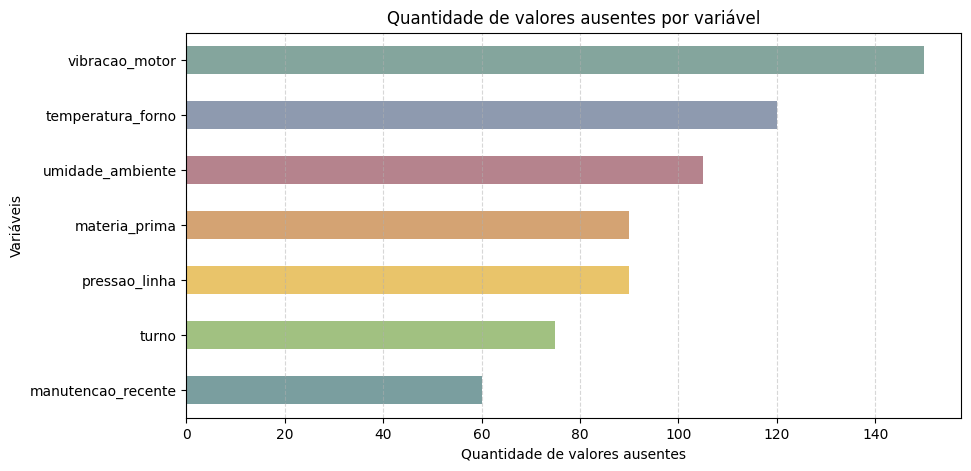

In [27]:
# Quais variáveis parecem conter mais ruído?
# Para responder, eu levei em conta a quantidade de valores ausentes em cada variável.

print("Quais variáveis parecem conter mais ruído?\n")
print("Eu olhei a quantidade de valores ausentes para decidir quais variáveis parecem ter mais ruído.\n")

ruido = df.isnull().sum()
ruido = ruido[ruido > 0].sort_values()

print("Variáveis que parecem conter mais ruído por causa disso:\n")
print(ruido.to_string())

cores = ["#7A9E9F", "#A1C181", "#E9C46A", "#D4A373", "#B5838D", "#8E9AAF", "#84A59D"]

plt.figure(figsize=(10,5))
ruido.plot(kind="barh", color=cores[:len(ruido)])
plt.title("Quantidade de valores ausentes por variável")
plt.xlabel("Quantidade de valores ausentes")
plt.ylabel("Variáveis")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

Na minha opinião, eu entendi que os outliers são os casos das variáveis que possuem mais valores ausentes
e os valores que mais fogem da média, pelo que eu calculei de cabeça observando os dados.



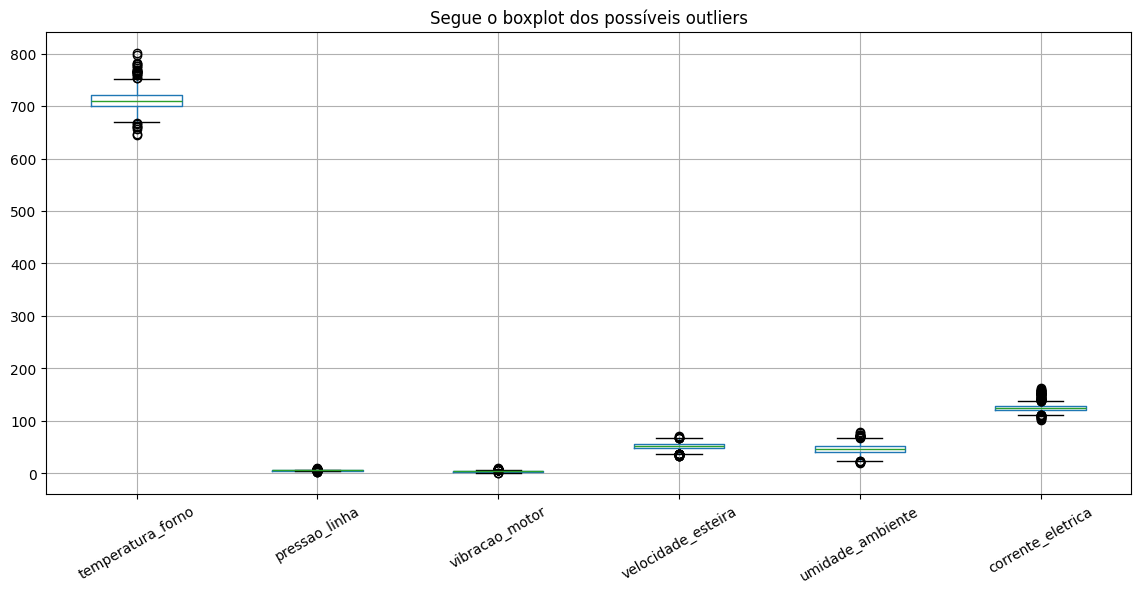

In [30]:
# Identifique visualmente possíveis outliers.

print("Na minha opinião, eu entendi que os outliers são os casos das variáveis que possuem mais valores ausentes\n"
      "e os valores que mais fogem da média, pelo que eu calculei de cabeça observando os dados.\n")

plt.figure(figsize=(14,6))
df[num_cols].boxplot(rot=30)
plt.title("Segue o boxplot dos possíveis outliers")
plt.show()

 Segue a versão em pairplot .



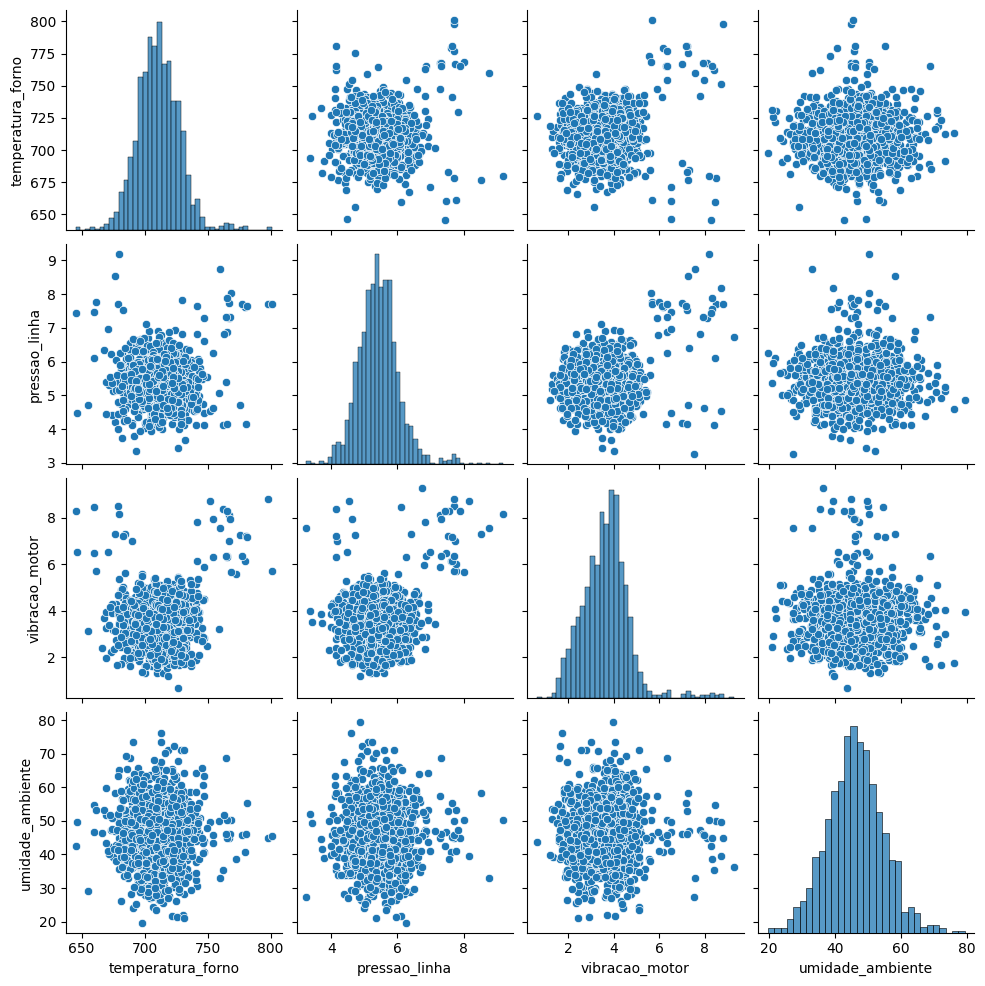

In [32]:
# Pairplot com algumas variáveis numéricas
import seaborn as sns

print(" Segue a versão em pairplot .\n")

sns.pairplot(df[["temperatura_forno", "pressao_linha", "vibracao_motor", "umidade_ambiente"]])
plt.show()


## 2-Imputação de Dados

Aplique as seguintes técnicas separadamente:

- Valor constante ("Desconhecido")
- Média
- Mediana
- Moda
- KNN Imputer

### Tarefas:

1. Crie **5 versões da base de dados**, uma para cada técnica.  
2. Compare estatísticas (média, desvio padrão) antes e depois da imputação.  
3. Qual técnica alterou mais a distribuição dos dados?  
4. Em quais situações a mediana é melhor que a média?

Existe uma técnica claramente melhor?



In [33]:
print("2-Imputação de Dados\n")
print("1) Criando 5 versões da base.\n")

from sklearn.impute import SimpleImputer, KNNImputer

num_cols = df.select_dtypes(include=["float64", "int64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

# valor constante
base_constante = df.copy()
base_constante[num_cols] = SimpleImputer(strategy="constant", fill_value=-1).fit_transform(base_constante[num_cols])
base_constante[cat_cols] = SimpleImputer(strategy="constant", fill_value="Desconhecido").fit_transform(base_constante[cat_cols])
print("Agora fiz a base com valor constante.")

# média
base_media = df.copy()
base_media[num_cols] = SimpleImputer(strategy="mean").fit_transform(base_media[num_cols])
base_media[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(base_media[cat_cols])
print("Agora fiz a base com média.")

# mediana
base_mediana = df.copy()
base_mediana[num_cols] = SimpleImputer(strategy="median").fit_transform(base_mediana[num_cols])
base_mediana[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(base_mediana[cat_cols])
print("Agora fiz a base com mediana.")

# moda
base_moda = df.copy()
base_moda[num_cols] = SimpleImputer(strategy="most_frequent").fit_transform(base_moda[num_cols])
base_moda[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(base_moda[cat_cols])
print("Agora fiz a base com moda.")

# knn
base_knn = df.copy()
base_knn[num_cols] = KNNImputer(n_neighbors=5).fit_transform(base_knn[num_cols])
base_knn[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(base_knn[cat_cols])
print("Agora fiz a base com KNN.")

2-Imputação de Dados

1) Criando 5 versões da base.

Agora fiz a base com valor constante.
Agora fiz a base com média.
Agora fiz a base com mediana.
Agora fiz a base com moda.
Agora fiz a base com KNN.



## 3-Detecção de Ruído e Outliers


1. Aplique DBSCAN com diferentes valores de `eps`.  
2. Quantos pontos foram classificados como ruído (`label = -1`)?  
3. Como o parâmetro `eps` influencia o resultado?
4. Identifique os outliers locais com LOF.  
5. Compare com DBSCAN:  
   - Quais pontos coincidem?  
   - Quais diferem?



In [35]:
print("-Detecção de Ruído e Outliers\n")
print("1) Primeiro eu preparei os dados numéricos e normalizei eles para poder usar no DBSCAN e no LOF.\n")

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor

# pegando só as colunas numéricas
X = df.select_dtypes(include=["float64", "int64"])

# preenchendo valores ausentes pela mediana
X = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X), columns=X.columns)

# escalando os dados
X_scaled = StandardScaler().fit_transform(X)

print("Agora os dados ficaram prontos.\n")

print("2) Apliquei o DBSCAN com diferentes valores de EPS'S.\n")

eps_valores = [0.5, 1.0, 1.5, 2.0]

for eps in eps_valores:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    ruido = (labels == -1).sum()
    print(f"Com eps = {eps}, a quantidade de pontos classificados como ruído foi: {ruido}")

print("\n3) Como o parâmetro eps influencia o resultado?\n")
print("Pelo que eu observei, quando o eps é menor, o DBSCAN tende a marcar mais pontos como ruído.")
print("Quando o eps aumenta, mais pontos entram nos grupos e a quantidade de ruído costuma diminuir.\n")

print("4) Agora apliquei o LOF para identificar outliers locais.\n")

lof = LocalOutlierFactor(n_neighbors=20)
lof_labels = lof.fit_predict(X_scaled)

outliers_lof = (lof_labels == -1).sum()

print(f"A quantidade de outliers encontrados pelo LOF foi: {outliers_lof}")

print("\n5) Comparei o LOF com o DBSCAN usando eps = 1.0.\n")

dbscan = DBSCAN(eps=1.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

ruido_dbscan = (dbscan_labels == -1)
outlier_lof = (lof_labels == -1)

coincidem = ((ruido_dbscan == True) & (outlier_lof == True)).sum()
diferem = (ruido_dbscan != outlier_lof).sum()

print(f"Quantidade de pontos que coincidem nos dois métodos: {coincidem}")
print(f"Quantidade de pontos que diferem entre os dois métodos: {diferem}\n")

print("6) O que eu entendi dessa comparação?\n")
print("Na minha visão, alguns pontos coincidem entre DBSCAN e LOF,")
print("porque os dois métodos tentam encontrar observações fora do padrão.")
print("Mas também existem diferenças, porque cada técnica usa um critério diferente.")

-Detecção de Ruído e Outliers

1) Primeiro eu preparei os dados numéricos e normalizei eles para poder usar no DBSCAN e no LOF.

Agora os dados ficaram prontos.

2) Apliquei o DBSCAN com diferentes valores de eps.

Com eps = 0.5, a quantidade de pontos classificados como ruído foi: 1500
Com eps = 1.0, a quantidade de pontos classificados como ruído foi: 694
Com eps = 1.5, a quantidade de pontos classificados como ruído foi: 164
Com eps = 2.0, a quantidade de pontos classificados como ruído foi: 58

3) Como o parâmetro eps influencia o resultado?

Pelo que eu observei, quando o eps é menor, o DBSCAN tende a marcar mais pontos como ruído.
Quando o eps aumenta, mais pontos entram nos grupos e a quantidade de ruído costuma diminuir.

4) Agora apliquei o LOF para identificar outliers locais.

A quantidade de outliers encontrados pelo LOF foi: 73

5) Comparei o LOF com o DBSCAN usando eps = 1.0.

Quantidade de pontos que coincidem nos dois métodos: 73
Quantidade de pontos que diferem entre o

## 4-Encoding de Variáveis Categóricas

Aplique:

- Label Encoding  
- One-Hot Encoding  
- Binary Encoding  
- Ordinal Encoding  
- Frequency Encoding  


1. Compare o número de colunas geradas em cada técnica.  
2. Qual técnica aumenta mais a dimensionalidade?  
3. Qual técnica preserva relações de ordem?  
4. Qual técnica você usaria para:
   - Árvores de decisão?
   - Regressão linear?
   - Redes neurais?

---


In [40]:
print("4-Encoding de Variáveis Categóricas\n")
print("Agora eu apliquei algumas técnicas de encoding nas variáveis categóricas.\n")

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
import pandas as pd

# pegando colunas categóricas
cat_cols = df.select_dtypes(include=["object"]).columns

print("As colunas categóricas que eu encontrei foram:")
print(cat_cols)
print()

# preenchendo valores ausentes das categóricas com a moda
df_cat = df[cat_cols].copy()
df_cat = df_cat.fillna(df_cat.mode().iloc[0])

# 1) Label Encoding
df_label = df_cat.copy()
label_encoder = LabelEncoder()

for col in df_label.columns:
    df_label[col] = label_encoder.fit_transform(df_label[col])

print("Agora fiz o Label Encoding.")

# 2) One-Hot Encoding
df_onehot = pd.get_dummies(df_cat, drop_first=False)

print("Agora fiz o One-Hot Encoding.")

# 3) Binary Encoding (jeito simples, usando os códigos e depois binário)
df_binary = pd.DataFrame()

for col in df_cat.columns:
    codigos = pd.factorize(df_cat[col])[0]
    binarios = [format(x, "b") for x in codigos]
    max_bits = max(len(b) for b in binarios)
    binarios = [b.zfill(max_bits) for b in binarios]

    for i in range(max_bits):
        df_binary[f"{col}_bin_{i+1}"] = [int(b[i]) for b in binarios]

print("Agora fiz o Binary Encoding.")

# 4) Ordinal Encoding
ordinal_encoder = OrdinalEncoder()
df_ordinal = pd.DataFrame(
    ordinal_encoder.fit_transform(df_cat),
    columns=df_cat.columns
)

print("Agora fiz o Ordinal Encoding.")

# 5) Frequency Encoding
df_frequency = pd.DataFrame()

for col in df_cat.columns:
    frequencia = df_cat[col].value_counts(normalize=True)
    df_frequency[col] = df_cat[col].map(frequencia)

print("Agora fiz o Frequency Encoding.\n")


print("1) Comparando o número de colunas geradas em cada técnica.\n")

print("Label Encoding:", df_label.shape[1], "colunas")
print("One-Hot Encoding:", df_onehot.shape[1], "colunas")
print("Binary Encoding:", df_binary.shape[1], "colunas")
print("Ordinal Encoding:", df_ordinal.shape[1], "colunas")
print("Frequency Encoding:", df_frequency.shape[1], "colunas")


print("\n2) Qual técnica aumenta mais a dimensionalidade?\n")
print("Na minha opinião, a técnica que mais aumenta a dimensionalidade é o One-Hot Encoding,")
print("porque ela cria uma coluna nova para cada categoria.\n")


print("3) Qual técnica preserva relações de ordem?\n")
print("Eu acho que a técnica que preserva melhor relações de ordem é o Ordinal Encoding.\n"
      "Isso porque ele transforma categorias em números, mas mantendo uma sequência.\n"
      "Por exemplo: baixo pode virar 1, médio pode virar 2 e alto pode virar 3.\n")


print("4) Qual técnica eu usaria em alguns modelos?\n")
print("Árvores de decisão: eu usaria o Ordinal Encoding.\n"
      "Regressão linear: eu usaria mais o One-Hot Encoding,\n"
      "porque ele separa as categorias em colunas diferentes , no eu acho mais clean e bonito.\n"
       "Redes neurais: eu também usaria mais o One-Hot Encoding,\n"


SyntaxError: incomplete input (1666524791.py, line 90)


## Exercícios opcionais

Escolha:

- Uma técnica de imputação  
- Uma técnica de encoding  

Treine um modelo de classificação e responda:

1. Qual combinação gerou melhor desempenho?  
2. Existe trade-off entre complexidade e desempenho?  
3. O resultado faz sentido do ponto de vista do problema?

4. Combine:
   - Detecção de outliers + remoção + imputação  
5. Re-treine o modelo  
6. Compare com o modelo original  

Limpar os dados sempre melhora o desempenho?
